## Notebook for satellite-based simulation output including feedbacks

This notebook contains postprocessing analysis of simulations initialized on a satellite-based grid. The simulations that are compared are:
1. Simulation without Stokes drift
2. Simulation with Stokes drift & constant depth extent of 1 m
3. Simulation with Stokes drift & constant depth extent of 1 m
4. Simulation with Stokes drift & varying depth extent based on relative biomass
5. Simulation with Stokes drift & wave damping based on relative biomass 

- D
- 

In [1]:

import parcels
import math
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import scipy

import trajan
import cartopy.crs as ccrs
import cartopy.feature
from datetime import datetime, timedelta
import calculate_distance as c_d
import calculate_2DHistogram_method01 as c_H
import grid_initialization as gi
import matplotlib.colors as mcolors
import cmocean.cm as cmo
from matplotlib import colormaps as mcolormaps

In [2]:
#Opening dataset of Lagrangian simulation based on satellite data release locations


# DS_ref = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/FINAL/SIM_sat_LA_2024_07_01_0.5.zarr").dropna(dim='obs', how='all')

# DS_nostokes = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/FINAL/SIM_sat_LA_2024_07_01_nostokes.zarr").dropna(dim='obs', how='all')

# DS_extent = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/FINAL/SIM_sat_LA_2024_07_01_0.5_extent.zarr").dropna(dim='obs', how='all')

# DS_damping = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/FINAL/SIM_sat_LA_2024_07_01_0.5_damping.zarr").dropna(dim='obs', how='all')


DS_ref = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/FINAL/SIM2_sat_LA_2024_07_01_0.5.zarr").dropna(dim='obs', how='all')

DS_nostokes = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/FINAL/SIM2_sat_LA_2024_07_01_nostokes.zarr").dropna(dim='obs', how='all')

DS_extent = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/FINAL/SIM2_sat_LA_2024_07_01_0.5_extent.zarr").dropna(dim='obs', how='all')

DS_damping = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/FINAL/SIM2_sat_LA_2024_07_01_0.5_damping.zarr").dropna(dim='obs', how='all')

DS_1 = xr.open_zarr("/storage/shared/oceanparcels/output_data/data_Elena/SATELLITE_OUT/SIM4_LA_2024_07_01_kN=0.001.zarr").dropna(dim='obs', how='all')
#Starttime definitions
starttimejul = datetime(2024,7,1)
starttimeaug = datetime(2024,8,1)



#Definition of time array
DSL1=DS_ref
time_in_hours = ((DSL1['time']-DSL1['time'][:,0]).astype("timedelta64[h]"))
time_in_days = ((DSL1['time'] - DSL1['time'][:, 0]).astype("timedelta64[h]")).astype(float) / 24

print('Size of DS1 file:' , DSL1.sizes)

print(DS_ref.sizes, DS_damping.sizes, DS_extent.sizes)


Size of DS1 file: Frozen({'trajectory': 103614, 'obs': 372})
Frozen({'trajectory': 103614, 'obs': 372}) Frozen({'trajectory': 103614, 'obs': 372}) Frozen({'trajectory': 103614, 'obs': 372})


In [3]:
import shapely
import geopandas as gpd

caribbean_poly = gpd.read_file("CARIBBEAN_polygon.shp")


def in_polygon_function(ds, poly):
    """Return a boolean DataArray marking points inside the polygon."""
    # Create shapely Point objects for all (lon, lat) pairs
    points = shapely.points(ds.lon, ds.lat)

    # Vectorized containment check (returns a boolean NumPy array)
    mask = shapely.contains(poly, points)

    # Wrap it back into an xarray DataArray with original coordinates
    return xr.DataArray(mask, coords=ds.coords)




def amount_in_car(input_dataset):
    caribbean_poly = gpd.read_file("CARIBBEAN_polygon.shp")
    data_in_polygon = in_polygon_function(input_dataset, caribbean_poly.geometry.iloc[0])
    # Count how many are True at obs = 0
    n_true_start = data_in_polygon.isel(obs=0).sum().item()

    # Count how many are True at the last obs
    n_true_end = data_in_polygon.isel(obs=-1).sum().item()

    print(f"True at obs=0, so amount of particles in Car initially: {n_true_start}")
    print(f"True at last obs, so amount of particles in Car after simulation: {n_true_end}")

    total = input_dataset.sizes["trajectory"]
    print(f"Start: {n_true_start/total:.3%}")
    print(f"End:   {n_true_end/total:.3%}")
    print(f"Relative:   {(n_true_end-n_true_start)/total:.3%}")
    print('')

    return data_in_polygon

labels = ['DE = 0.5', 'No Stokes', 'Biomass-dependent extent', 'Wave damping', 'DE = 1']
amount_in_car( DS_ref)
amount_in_car(DS_nostokes)
amount_in_car( DS_extent)
amount_in_car(DS_damping)
amount_in_car( DS_1)

True at obs=0, so amount of particles in Car initially: 3469
True at last obs, so amount of particles in Car after simulation: 18812
Start: 3.348%
End:   18.156%
Relative:   14.808%

True at obs=0, so amount of particles in Car initially: 3469
True at last obs, so amount of particles in Car after simulation: 14005
Start: 3.348%
End:   13.517%
Relative:   10.169%

True at obs=0, so amount of particles in Car initially: 3469
True at last obs, so amount of particles in Car after simulation: 18827
Start: 3.348%
End:   18.170%
Relative:   14.822%

True at obs=0, so amount of particles in Car initially: 3469
True at last obs, so amount of particles in Car after simulation: 18786
Start: 3.348%
End:   18.131%
Relative:   14.783%

True at obs=0, so amount of particles in Car initially: 3490
True at last obs, so amount of particles in Car after simulation: 18148
Start: 3.367%
End:   17.510%
Relative:   14.143%



<xarray.DataArray (trajectory: 103642, obs: 372)> Size: 39MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(103642, 372))
Coordinates:
  * obs         (obs) int32 1kB 0 1 2 3 4 5 6 7 ... 365 366 367 368 369 370 371
  * trajectory  (trajectory) int64 829kB 0 1 2 3 ... 103638 103639 103640 103641

In [20]:
#delta_x = math.sqrt( (DS_ref.lon[:,-1].values - DS_extent.lon[:,-1].values)**2 + (DS_ref.lat[:,-1].values - DS_extent[:,-1].values)**2 )

delta_extent = np.sqrt((DS_ref.lon.values[:, -1] - DS_extent.lon.values[:, -1])**2 + (DS_ref.lat.values[:, -1] - DS_extent.lat.values[:, -1])**2)

delta_extent_av = np.average(delta_extent)


delta_no = np.sqrt((DS_ref.lon.values[:, -1] - DS_nostokes.lon.values[:, -1])**2 + (DS_ref.lat.values[:, -1] - DS_nostokes.lat.values[:, -1])**2)

delta_no_av = np.average(delta_no)




print(delta_extent_av)
print(delta_no_av)





0.023420755368096798
1.7631096891156783


Frozen({'trajectory': 103614, 'obs': 372})
Frozen({'trajectory': 103614, 'obs': 372})
Frozen({'trajectory': 103642, 'obs': 372})
Frozen({'trajectory': 103614, 'obs': 372})
(4, 372) (4, 372)
372 Stokes, DE = 0.5 m: 10.361 %
372 Stokes, DE = 0.5 m & wave damping: 10.313 %
372 Stokes, DE = 1 m: 10.033 %
372 No Stokes: 5.565 %


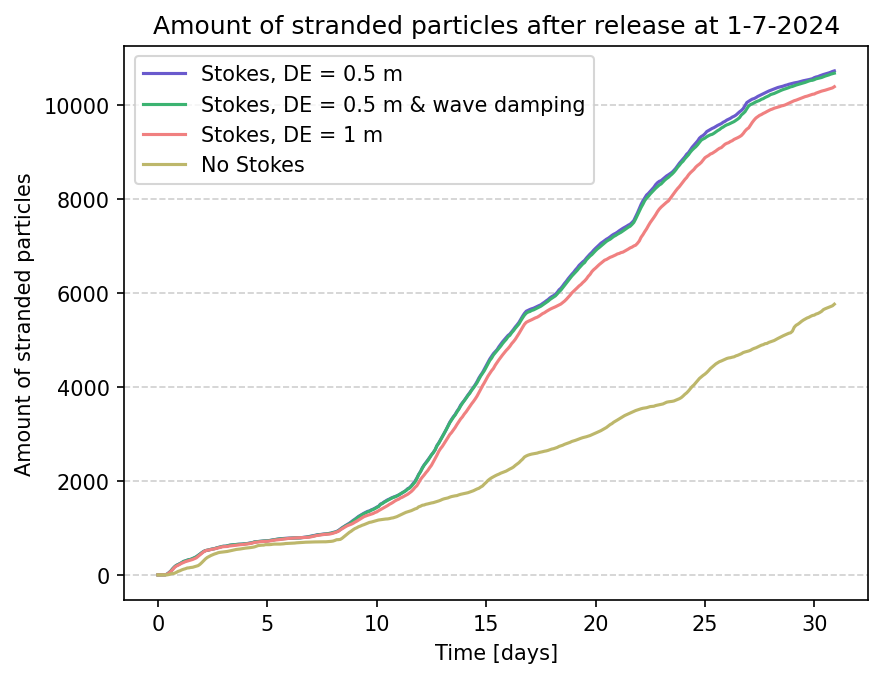

In [15]:
datasets_to_check = [DS_ref, DS_nostokes, DS_extent, DS_damping, DS_1]
datasets_to_check2 = [DS_ref,  DS_damping, DS_1, DS_nostokes]
labels = ['DE = 0.5', 'No Stokes', 'Biomass-dependent extent', 'Wave damping', 'DE = 1']
labels2 = ['Stokes, DE = 0.5 m', 'Stokes, DE = 0.5 m & wave damping', 'Stokes, DE = 1 m' , 'No Stokes']
colors = [ 'slateblue', 'mediumseagreen', 'lightcoral', 'darkkhaki']


strand = []
strand_percentage = []

for ds in datasets_to_check2:
    # sum stranded particles along the obs dimension (axis=0)
    print(ds.sizes)
    stranded_sum = np.sum(ds.stranded[:,:], axis=0)
    strand.append(stranded_sum)
    stranded_percentage = 100 * stranded_sum / len(ds.trajectory)
    strand_percentage.append(stranded_percentage)

#Convert to a numpy array if needed
strand = np.array(strand)
strand_percentage=np.array(strand_percentage)
print(strand.shape, strand_percentage.shape)

fig = plt.figure(dpi=150)
for i in range(len(datasets_to_check2)):
    until = 372
    print(until, f'{labels2[i]}: {strand_percentage[i,-1]:.3f} %')
    plt.plot(time_in_days[0,:until], strand[i,:until], label = f'{labels2[i]}', color=colors[i])
#lt.plot(time_in_days[0,:], strand)
plt.xlabel('Time [days]')
plt.ylabel('Amount of stranded particles')
plt.legend()
plt.title(f'Amount of stranded particles after release at 1-7-2024')
#plt.title(f'Stranded particels = {(100*strand[-1].values/(len(DSL1.trajectory))):.2f} % of total')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [ ]:

trajmean_lim_sal =    np.array([E['lim_salinity'].mean(dim='trajectory')  for E in datasets_to_check] )
trajmean_lim_temp =   np.array([E['lim_temp'].mean(dim='trajectory')      for E in datasets_to_check] )
trajmean_lim_no3 =    np.array([E['lim_no3'].mean(dim='trajectory')       for E in datasets_to_check] )
trajmean_lim_E_tot =  np.array([E['limitation'].mean(dim='trajectory')    for E in datasets_to_check] )
trajmean_biomass =  np.array([E['biomass_SF3'].mean(dim='trajectory')    for E in datasets_to_check] )

print(trajmean_biomass[:,-1])

[1.4260579 1.4390081 1.4261765 1.4269314 1.4288068]


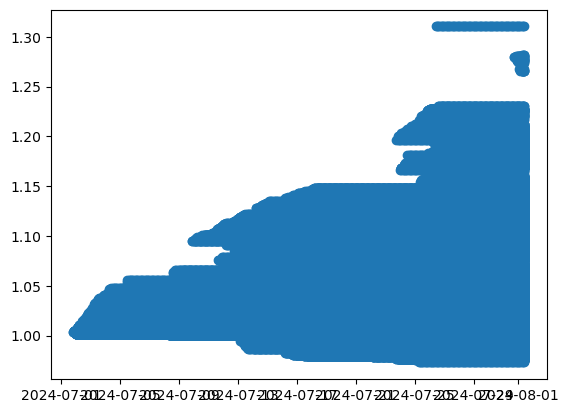

In [23]:
stranded_traj = DS_ref.where(DS_ref.stranded == 1)

plt.scatter(stranded_traj.time, stranded_traj.biomass_SF3)
plt.show()

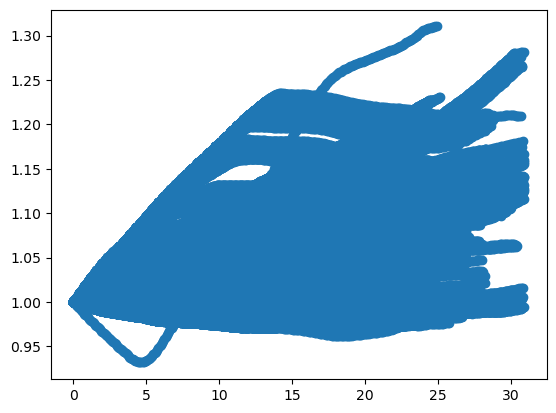

In [ ]:
# Boolean mask of stranded points
is_stranded = DS_ref.stranded == 1

# Find first stranding index along obs for each trajectory
first_idx = is_stranded.argmax(dim="obs")

# Mask trajectories that never strand
has_stranded = is_stranded.any(dim="obs")

# Build mask: keep only obs <= first stranding index
obs_index = xr.DataArray(
    np.arange(DS_ref.sizes["obs"]),
    dims="obs"
)

mask = (obs_index <= first_idx) & has_stranded

# Apply mask to whole dataset
DS_first_strand = DS_ref.where(mask)

# Should be exactly one "1" per stranded trajectory
stranded_first.sum(dim="obs")

plt.scatter(time_in_days, DS_first_strand.biomass_SF3)
plt.show()

In [7]:
import geopandas as gpd
from shapely.geometry import Point, Polygon
import shapely

SEA = """Caribbean Sea	21.60000	-87.07500	250001006	1
Caribbean Sea	21.86700	-84.95000	250001006	2
Caribbean Sea	22.81400	-82.58600	250001006	3
Caribbean Sea	22.81400	-81.12000	250001006	4
Caribbean Sea	20.06700	-74.29600	250001006	5
Caribbean Sea	19.75000	-73.42100	250001006	6
Caribbean Sea	18.60800	-68.32500	250001006	7
Caribbean Sea	18.47900	-67.16700	250001006	8
Caribbean Sea	18.38200	-65.64400	250001006	9
Caribbean Sea	18.38200	-62.19000	250001006	10
Caribbean Sea	13.25000	-59.12000	250001006	11
Caribbean Sea	10.83600	-60.90800	250001006	12
Caribbean Sea	10.13700	-60.99200	250001006	13
Caribbean Sea	9.51700	-60.96700	250001006	14
Caribbean Sea	8.65000	-62.46000	250001006	15
Caribbean Sea	7.42000	-76.37000	250001006	16
Caribbean Sea	8.00000	-77.70000	250001006	17
Caribbean Sea	9.15000	-78.40000	250001006	18
Caribbean Sea	9.15000	-79.50000	250001006	19
Caribbean Sea	8.20000	-80.70000	250001006	20
Caribbean Sea	8.61000	-82.27000	250001006	21
Caribbean Sea	14.00000	-86.00000	250001006	22
Caribbean Sea	15.00000	-90.00000	250001006	23
Caribbean Sea	21.60000	-87.07500	250001006	24"""

def get_sea_points():
    points = []
    for line in SEA.splitlines():
        _, lat, lon, _, _ = line.split("\t")
        points.append((float(lon), float(lat)))
    return points
get_sea_points()

# Create Shapely Point geometries
coords = get_sea_points()
# Create shapely points
geometry = [Point(lon, lat) for lon, lat in coords]
gdf = gpd.GeoDataFrame(
    {"Sea": ["Caribbean Sea"] * len(coords), "ID": list(range(1, len(coords)+1))},
    geometry=geometry,
    crs="EPSG:4326"
)

# Save as shapefile
outshapefile = "CARIBBEAN_points.shp"
gdf.to_file(outshapefile)

# Optionally: create a Polygon connecting those points
polygon = Polygon(coords)

# Save polygon shapefile too
gdf_poly = gpd.GeoDataFrame({"Sea": ["Caribbean Sea"]}, geometry=[polygon], crs="EPSG:4326")
gdf_poly.to_file("CARIBBEAN_polygon.shp")

def in_polygon(ds, poly: shapely.geometry.Polygon) -> xr.DataArray:
    """Return a boolean array indicating whether each point is in the given polygon.

    `shapely.points(...)` allows for the creation of points from arrays of lon/lat
    `shapely.geometry.Polygon.contains` is also compatible with arrays of points
    """
    array = poly.contains(shapely.points(ds.lon, ds.lat))
    return xr.DataArray(
        array, coords=ds.coords
    )  # Adding back the dimension information, as shapely didn't carry it through

hi = in_polygon(DSL1, gdf_poly)
def plot_polygon(poly: shapely.geometry.Polygon, ax=None):
    if ax is None:
        fig, ax = plt.subplots()
    ax.plot(*poly.exterior.xy)
    return fig, ax

# Plot polygon outline
fig, ax = plt.subplots(figsize=(8,6))
ax = plt.axes(projection=ccrs.PlateCarree())
gdf_poly.boundary.plot(ax=ax, color='blue')
gdf.plot(ax=ax, color='red', markersize=20)
plt.title("Caribbean Sea polygon and points")
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

TypeError: (<class 'geopandas.geoseries.GeoSeries'>, <class 'numpy.ndarray'>)

In [ ]:
import shapely
import xarray as xr

def in_polygon_function(ds, poly):
    """Return a boolean DataArray marking points inside the polygon."""
    # Create shapely Point objects for all (lon, lat) pairs
    points = shapely.points(ds.lon, ds.lat)

    # Vectorized containment check (returns a boolean NumPy array)
    mask = shapely.contains(poly, points)

    # Wrap it back into an xarray DataArray with original coordinates
    return xr.DataArray(mask, coords=ds.coords)

hi = in_polygon_function(DSL1, gdf_poly.geometry.iloc[0])
hi

<xarray.DataArray (trajectory: 78205, obs: 372)> Size: 29MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(78205, 372))
Coordinates:
  * obs         (obs) int32 1kB 0 1 2 3 4 5 6 7 ... 365 366 367 368 369 370 371
  * trajectory  (trajectory) int64 626kB 0 1 2 3 4 ... 78201 78202 78203 78204

In [ ]:
total_in_car_per_month = []

for L in DSLs[:]:
    caribbean_mask = in_polygon_function(L, gdf_poly.geometry.iloc[0])
    particles_in_car = L.where(caribbean_mask, drop = True)
    total_number_in_car = len(particles_in_car.trajectory)
    total_in_car_per_month.append(total_number_in_car)



numberincar = DSL2.where(hi, drop = True)
total_number = len(numberincar.trajectory)

print(total_number)
print(total_in_car_per_month)

4222
[4741, 4222, 3076, 3539, 4148, 2873, 3194, 2396, 1096, 1159, 2059, 2928]


In [7]:
def red_area_from_sat(image_name, north, south, east, west, coarse=False):

    #Loading the image as an RGB array
    from PIL import Image
    img = Image.open(image_name).convert("RGB")
    img_array = np.array(img)

    #Creating a mask only selects red regions of image
    r, g, b = img_array[:,:,0], img_array[:,:,1], img_array[:,:,2]

    red_mask = (
        (r > 150) &                 # strong red channel
        (g < 80)  &                 # green must be low
        (b < 80)  &                 # blue must be low
        ((r - g) > 70) &            # red clearly dominates over green
        ((r - b) > 70)              # red clearly dominates over blue
    )

    #Creating coordinate grids based on bounding boxes
    height, width = red_mask.shape
    lats = np.linspace(north, south, height)
    lons = np.linspace(west, east, width)

    #Creating 2D coordinate grids
    lon_grid, lat_grid = np.meshgrid(lons, lats)

    #Downsample with stride 2 if you want to select less particles
    stride = 2 if coarse else 1
    mask = red_mask[::stride, ::stride]
    lat = lat_grid[::stride, ::stride]
    lon = lon_grid[::stride, ::stride]

    amount = int(mask.sum())

    #Creating 2D grids of Sargassum release locations
    sarg_lon_grid = xr.DataArray(lon).where(mask == 1)
    sarg_lat_grid = xr.DataArray(lat).where(mask == 1)
    print('Shape of grid:', np.shape(sarg_lon_grid))

    #To prepare the grids as ParticleSet input, NaNs are removed and and arrays are ravelled (flattened)
    no_nan_mask = (~np.isnan(sarg_lon_grid)) & (~np.isnan(sarg_lat_grid)) 
    sarg_lon_grid = sarg_lon_grid.values[no_nan_mask].ravel()
    sarg_lat_grid = sarg_lat_grid.values[no_nan_mask].ravel()
    print('Reshaped grid as particle set:', np.shape(sarg_lon_grid))

    return sarg_lon_grid, sarg_lat_grid, amount


Shape of grid: (1210, 1375)
Reshaped grid as particle set: (24176,)


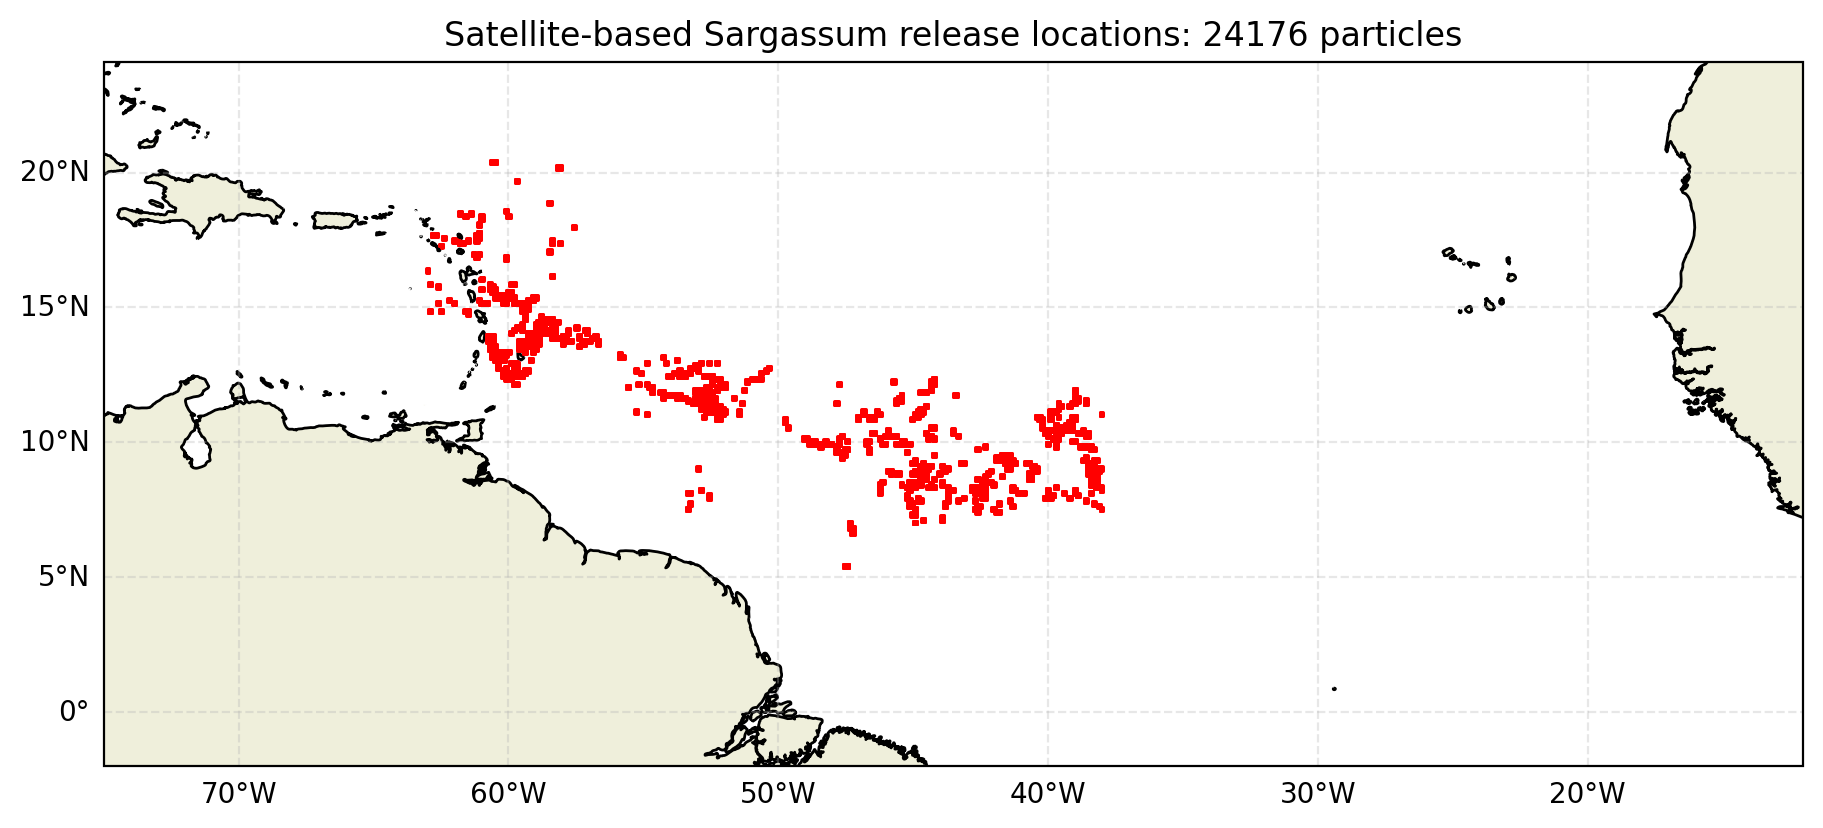

In [8]:
image_name_line = '/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png'

red_lon_grid_W, red_lat_grid_W, amount_red = red_area_from_sat(image_name_line, 22.0, 0.0, -38.0, -63.0, coarse=True)

fig = plt.figure(figsize = (9,4), constrained_layout=True, dpi=200)
ax = plt.axes(projection=ccrs.PlateCarree(),zorder=4)
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=2)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'), zorder=1)
ax.gridlines(draw_labels=['left','bottom'], zorder=0, alpha=0.3, linestyle='--')
ax.scatter(red_lon_grid_W, red_lat_grid_W, s = 1, marker = 's', color='red', zorder=5)
ax.set_extent([-75,-12, -2,21])
ax.set_title(f'Satellite-based Sargassum release locations: {amount_red} particles')
plt.show()

In [5]:
#August data to check
imgaug1 = "/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.C_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png"
imgaug2 = "/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.CE_ATLANTIC.7DAY.L3D.FA_UNET_DENSITY.png"
imgaug3 = '/nethome/6903894/testing/Input_data_test/C20242082024214.1KM.ECARIB.7DAY.L3D.FA_UNET_DENSITY.png'

aug_lon_C, aug_lat_C, amount_aug_C = gi.sarg_grid_from_sat(imgaug1, 22.0, 0.0, -38.0, -63.0, coarse=True)
aug_lon_CE, aug_lat_CE, amount_aug_CE = gi.sarg_grid_from_sat(imgaug2, 22.0, 0.0, -11.5, -38.0, coarse=True)
aug_lon_E, aug_lat_E, amount_aug_E = gi.sarg_grid_from_sat(imgaug3, 23.0, 10.0, -60.0, -75.0, coarse=True)

Shape of grid: (1210, 1375)
Reshaped grid as particle set: (106575,)
Shape of grid: (1210, 1458)
Reshaped grid as particle set: (22148,)
Shape of grid: (715, 825)
Reshaped grid as particle set: (51953,)


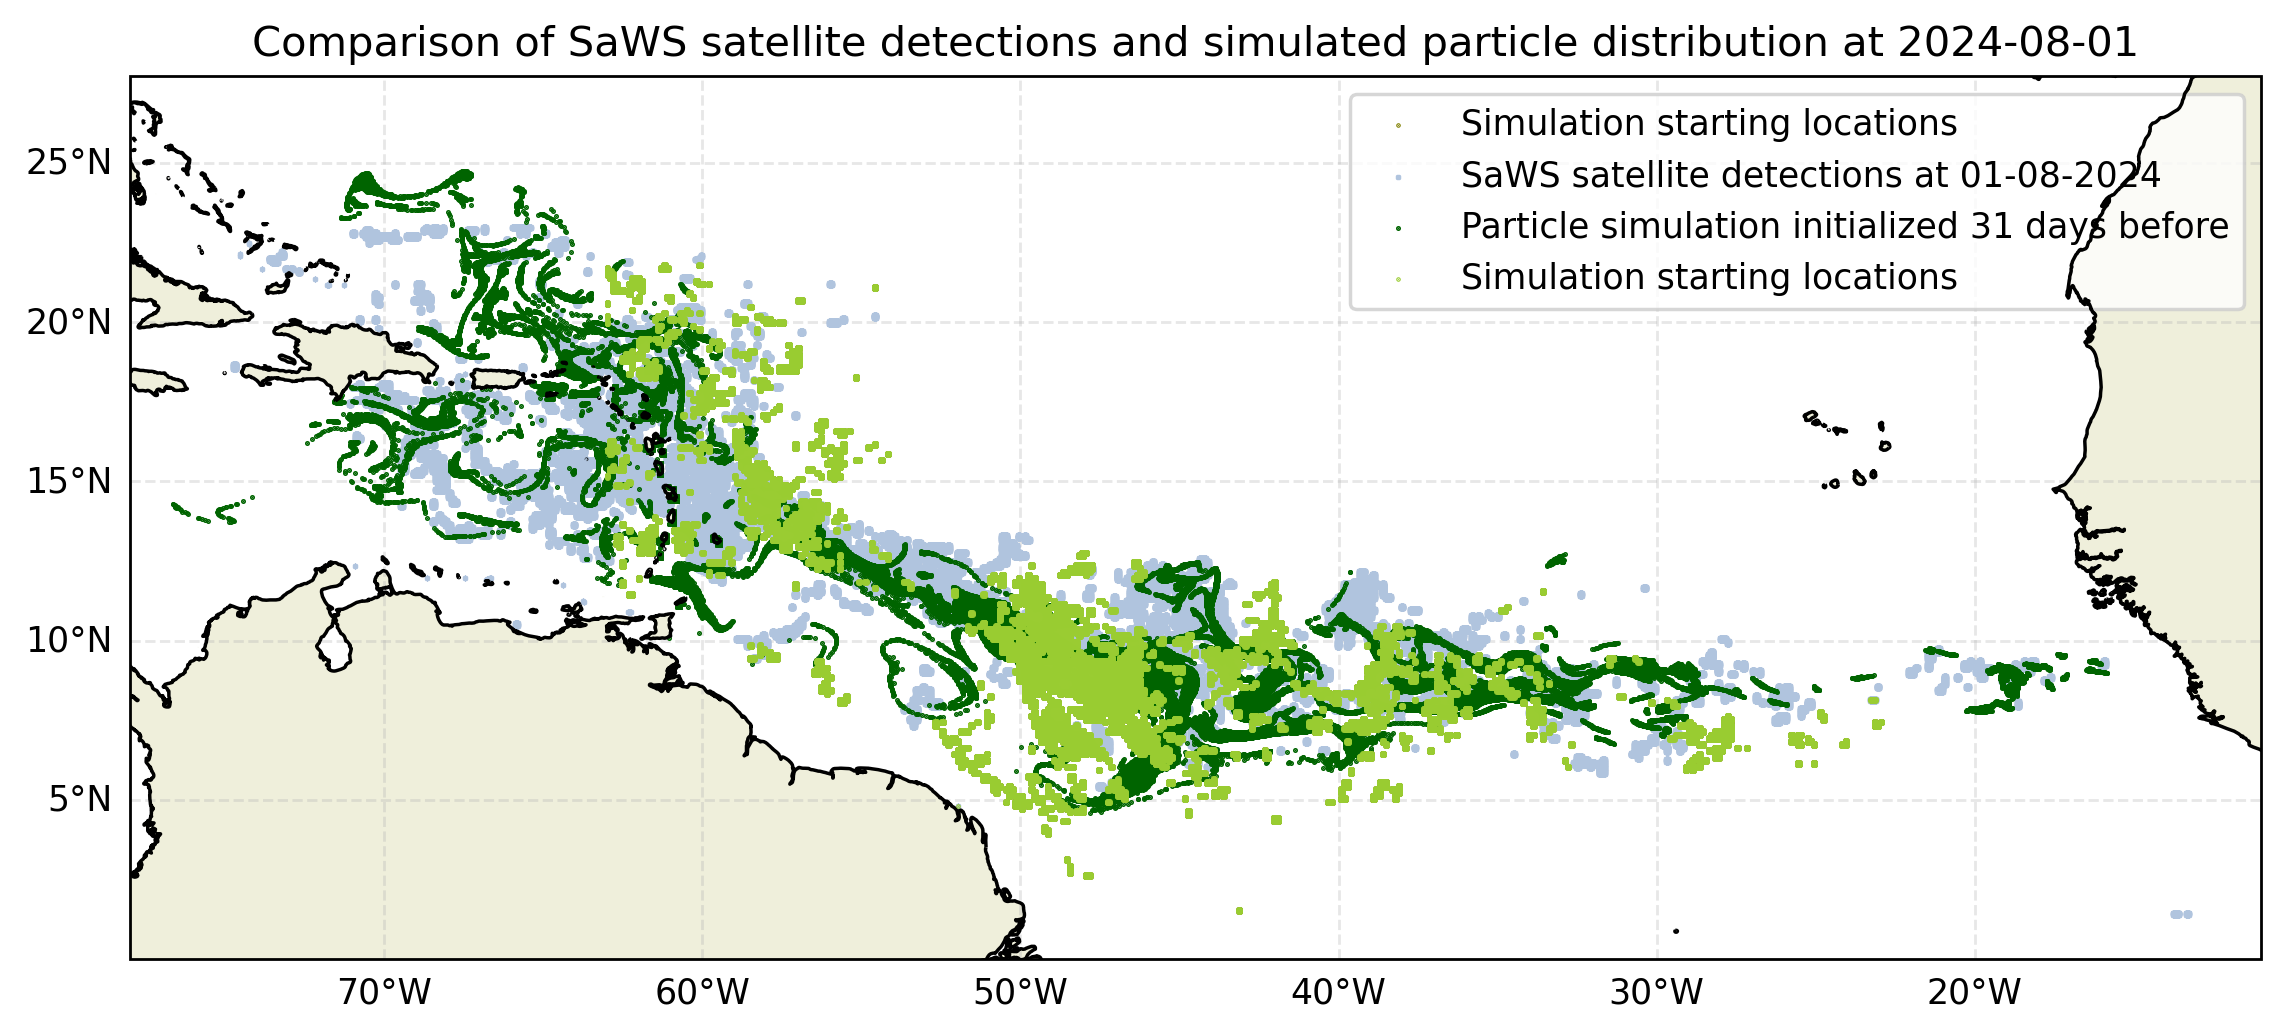

In [ ]:
import geopandas as gpd
from shapely.geometry import Point, Polygon
import shapely


#Figure for plotting trajectories
fig2 = plt.figure(figsize = (11,6), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

#Simulation start locations scatterplot
#splot = ax.scatter(DS_ref.lon[:,0], DS_ref.lat[:,0], s = 0.1 ,color='olive', label = 'Simulation starting locations') #Transposing lon and lat arrays!

#Satellite scatter plots
satplot = ax.scatter(aug_lon_C, aug_lat_C, s = 0.11, c='lightsteelblue', marker = 's', label='SaWS satellite detections at 01-08-2024',zorder=6)
satplot2 = ax.scatter(aug_lon_CE, aug_lat_CE, s = 0.1, c='lightsteelblue', marker = 's', zorder=6)
satplot3 = ax.scatter(aug_lon_E, aug_lat_E, s = 0.1, c='lightsteelblue', marker = 's', zorder=6)

#Simulation end location scatterplot
eplot = ax.scatter(DS_ref.lon[:,-1], DS_ref.lat[:,-1], s = 0.2 ,color='darkgreen', label = 'Particle simulation initialized 31 days before',zorder=7)

#ax.scatter(red_lon_grid_W, red_lat_grid_W, s = 0.2, marker = 's', color='red', alpha=0.3, zorder=8)

#Simulation start locations scatterplot
splot = ax.scatter(DS_ref.lon[:,0], DS_ref.lat[:,0], s = 0.1 ,color='yellowgreen', label = 'Simulation starting locations',zorder=9) #Transposing lon and lat arrays!

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=8)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))
ax.set_title(f'Comparison of SaWS satellite detections and simulated particle distribution at {starttimeaug.date()}')
ax.set_extent([-78,-11, 0,24])
ax.legend()
plt.show()

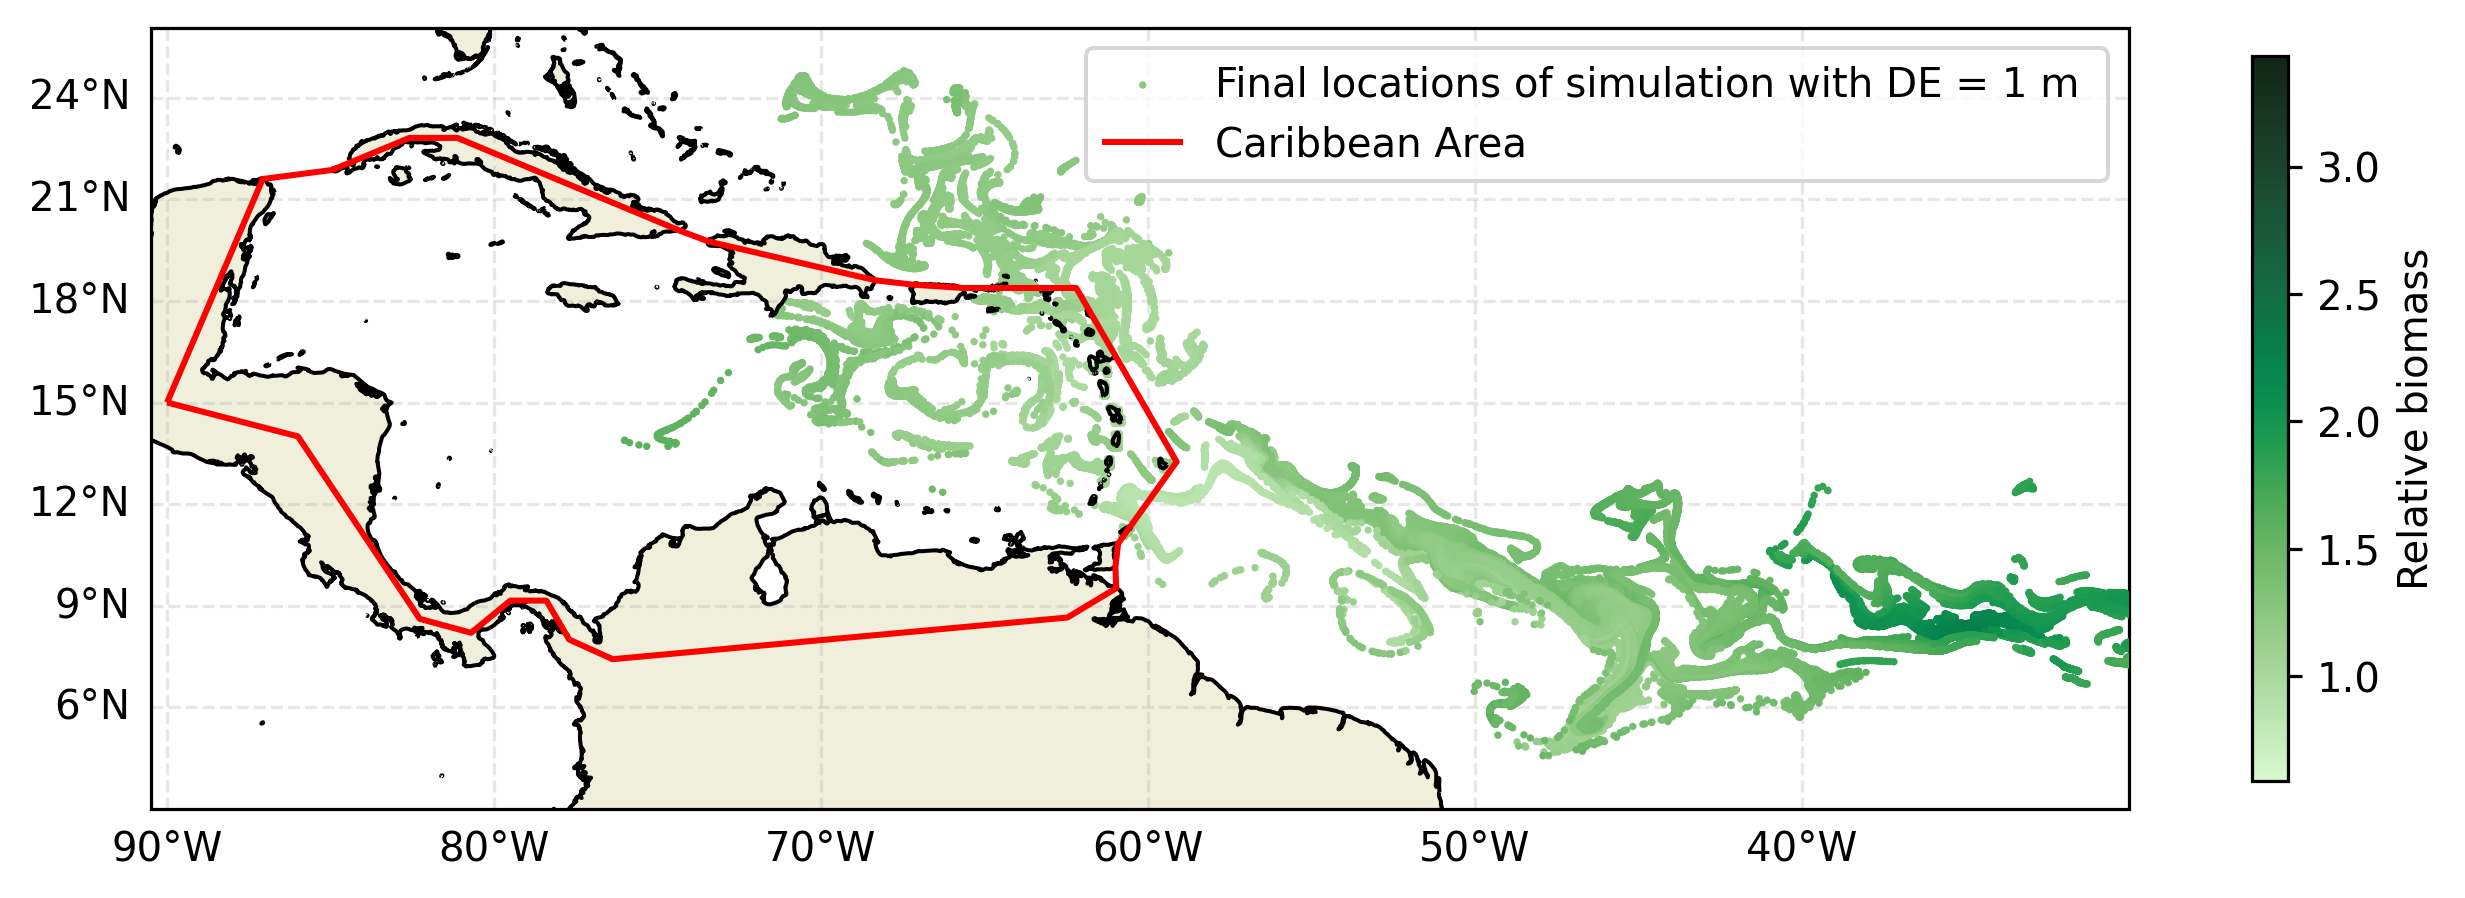

In [28]:
import geopandas as gpd
from shapely.geometry import Point, Polygon
import shapely

caribbean_poly = gpd.read_file("CARIBBEAN_polygon.shp")

#Figure for plotting trajectories
fig2 = plt.figure(figsize = (11,5), dpi=290)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

#Simulation end location scatterplot
eplot = ax.scatter(DS_1.lon[:,-1], DS_1.lat[:,-1], s = 0.7 ,c = DS_1.biomass_SF3[:,-1].values,
        cmap=cmo.algae, label = 'Final locations of simulation with DE = 1 m ',zorder=7)

caribbean_poly.boundary.plot(ax=ax, color='red',zorder=9, label='Caribbean Area ')
#gdf.plot(ax=ax, color='red', markersize=10,zorder=5)


ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'),zorder=8)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

ax.set_extent([-90.5,-30, 3,23])
cbar = plt.colorbar(eplot, ax=ax, orientation='vertical', label='Relative biomass', shrink=0.65)
ax.legend()

plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/feedbacks_car.pdf", format="pdf", bbox_inches="tight")
plt.savefig(f"/nethome/6903894/testing/THESIS_PLOTS/feedbacks_car.png", format="png", bbox_inches="tight")
plt.show()

In [8]:
import shapely
import xarray as xr
import geopandas as gpd

caribbean_poly = gpd.read_file("CARIBBEAN_polygon.shp")


def in_polygon_function(ds, poly):
    """Return a boolean DataArray marking points inside the polygon."""
    # Create shapely Point objects for all (lon, lat) pairs
    points = shapely.points(ds.lon, ds.lat)

    # Vectorized containment check (returns a boolean NumPy array)
    mask = shapely.contains(poly, points)

    # Wrap it back into an xarray DataArray with original coordinates
    return xr.DataArray(mask, coords=ds.coords)

hi = in_polygon_function(DSS1, caribbean_poly.geometry.iloc[0])
hi

<xarray.DataArray (trajectory: 103642, obs: 372)> Size: 39MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(103642, 372))
Coordinates:
  * obs         (obs) int32 1kB 0 1 2 3 4 5 6 7 ... 365 366 367 368 369 370 371
  * trajectory  (trajectory) int64 829kB 0 1 2 3 ... 103638 103639 103640 103641

In [16]:
# numberincar = DSS1.where(hi, drop = True)
# numberincar
#total_number = len(numberincar.trajectory)

#print(total_number)
import geopandas as gpd

def amount_in_car(input_dataset):
    caribbean_poly = gpd.read_file("CARIBBEAN_polygon.shp")
    data_in_polygon = in_polygon_function(input_dataset, caribbean_poly.geometry.iloc[0])
    # Count how many are True at obs = 0
    n_true_start = data_in_polygon.isel(obs=0).sum().item()

    # Count how many are True at the last obs
    n_true_end = data_in_polygon.isel(obs=-1).sum().item()

    print(f"True at obs=0, so amount of particles in Car initially: {n_true_start}")
    print(f"True at last obs, so amount of particles in Car after simulation: {n_true_end}")

    total = hi.sizes["trajectory"]
    print(f"Start: {n_true_start/total:.2%}")
    print(f"End:   {n_true_end/total:.2%}")

    return data_in_polygon
amount_in_car(DSS2de)

True at obs=0, so amount of particles in Car initially: 3490
True at last obs, so amount of particles in Car after simulation: 18755
Start: 3.37%
End:   18.10%


<xarray.DataArray (trajectory: 103642, obs: 372)> Size: 39MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(103642, 372))
Coordinates:
  * obs         (obs) int32 1kB 0 1 2 3 4 5 6 7 ... 365 366 367 368 369 370 371
  * trajectory  (trajectory) int64 829kB 0 1 2 3 ... 103638 103639 103640 103641

In [27]:
# Compute differences between consecutive observations along obs
# We pad with a False at the beginning to preserve shape
prev = hi.shift(obs=1, fill_value=False)

# Rising edge: False → True
first_true_after_false = hi & ~prev

# Falling edge: True → False
first_false_after_true = ~hi & prev

n_true_after_false = first_true_after_false.sum(dim="obs")
n_false_after_true = first_false_after_true.sum(dim="obs")
print("Rising edges:", int(first_true_after_false.sum()))
print("Falling edges:", int(first_false_after_true.sum()))

first_false_after_true

Rising edges: 20985
Falling edges: 2703


<xarray.DataArray (trajectory: 103642, obs: 372)> Size: 39MB
array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]],
      shape=(103642, 372))
Coordinates:
  * obs         (obs) int32 1kB 0 1 2 3 4 5 6 7 ... 365 366 367 368 369 370 371
  * trajectory  (trajectory) int64 829kB 0 1 2 3 ... 103638 103639 103640 103641

/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:498: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().get_tightbbox(renderer, *args, **kwargs)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  return super().draw(renderer=renderer, **kwargs)
/nethome/6903894/parcels_env/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:524: UserWarning: Creati

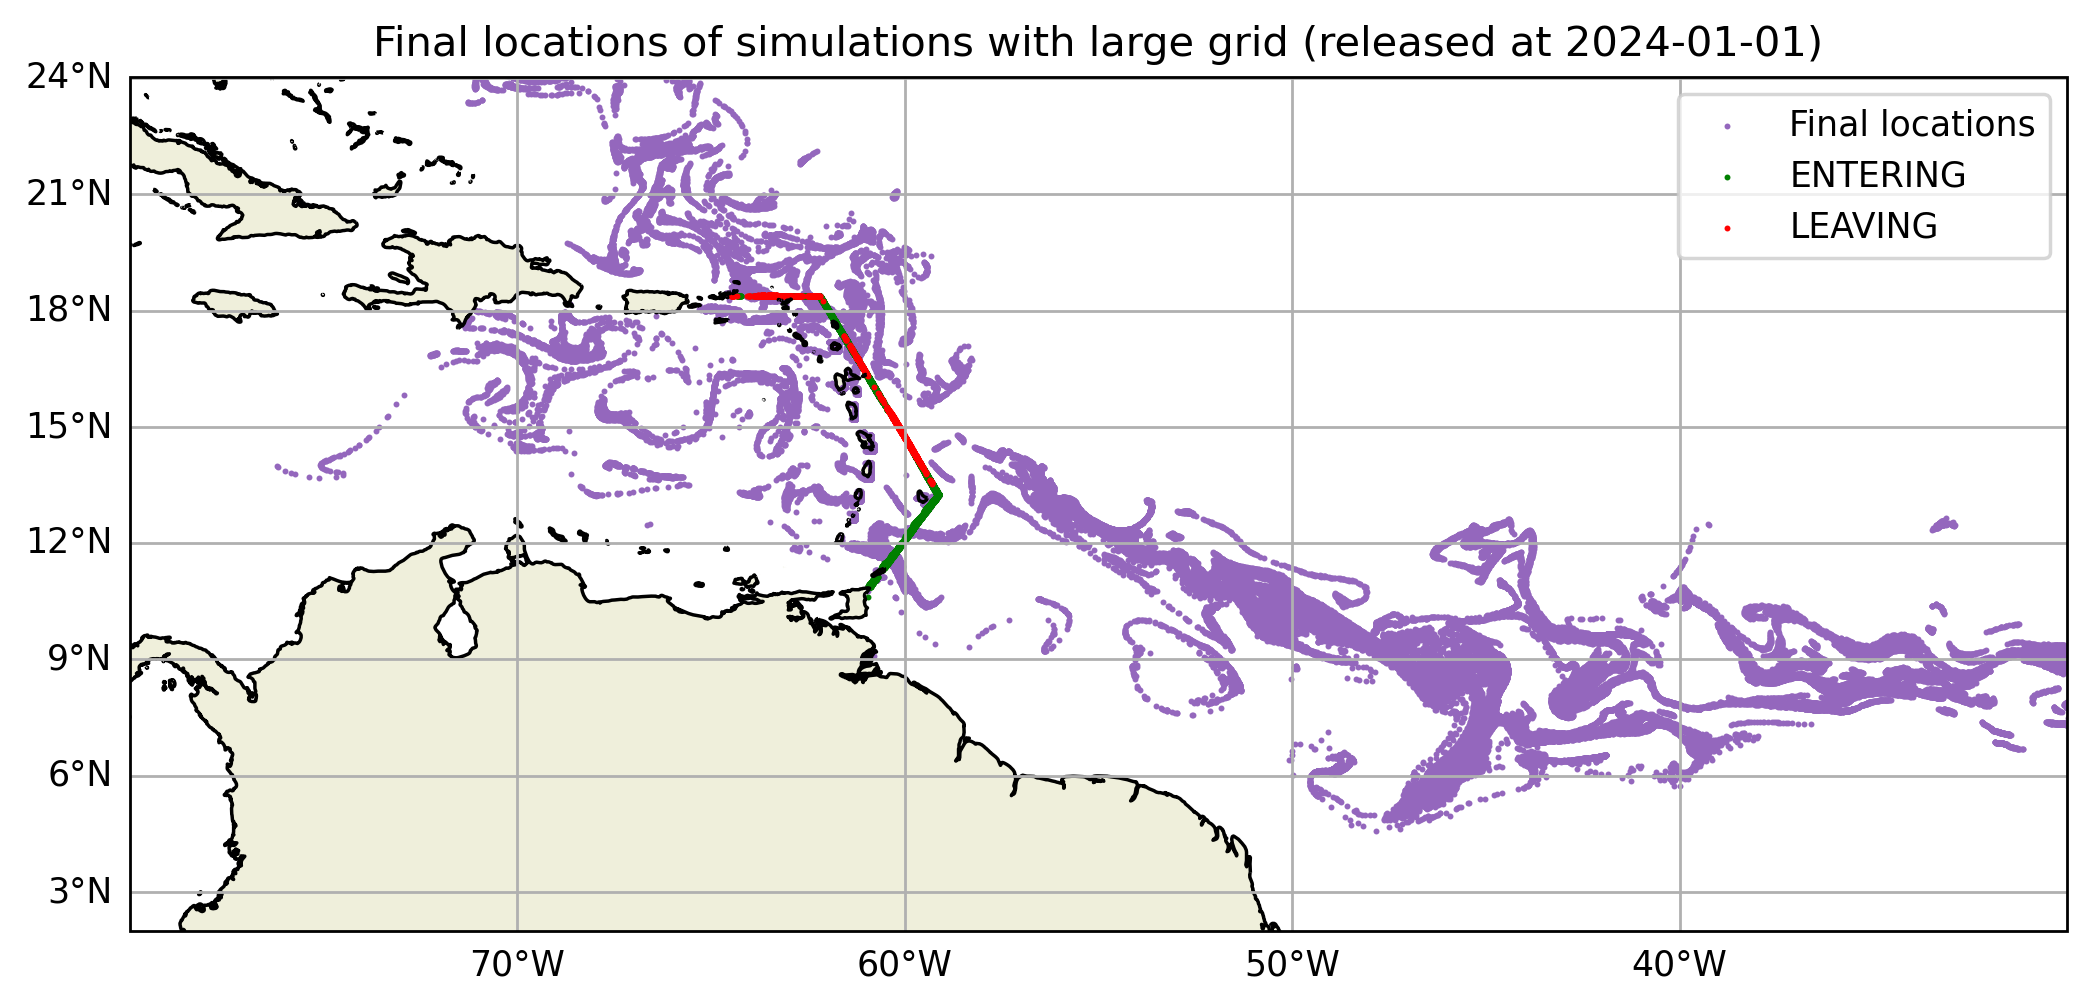

In [37]:
entering = DSS1.where(first_true_after_false, drop=False)
leaving = DSS1.where(first_false_after_true, drop=False)

#Figure for plotting trajectories
fig2 = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
#caribbean_poly.boundary.plot(ax=ax, color='blue')

#End locations scatterplot
#eplot = ax.scatter(DSL1.lon[:,-1], DSL1.lat[:,-1], s = 0.5 ,color='tab:red', label= 'Jan transport') #Transposing lon and lat arrays!
eplot = ax.scatter(DSS1.lon[:,-1], DSS1.lat[:,-1], s = 0.5 ,color='tab:purple', label = 'Final locations') #Transposing lon and lat arrays!

entplot = ax.scatter(entering.lon[:,1:], entering.lat[:,1:], s = 0.5, color= 'green', label='ENTERING')
leavplot = ax.scatter(leaving.lon[:,1:], leaving.lat[:,1:], s = 0.5, color= 'red', label='LEAVING')

ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'))
ax.add_feature(cartopy.feature.LAND.with_scale('10m'))

#gdf.plot(ax=ax, color='lightblue', markersize=20)
ax.gridlines(draw_labels=['left','bottom'], zorder=0)
ax.set_title(f'Final locations of simulations with large grid (released at {starttimejan.date()})')
ax.set_extent([-80,-30,2,22])
#ax.set_extent([-86,7,-7,19])
ax.legend()
plt.show()

In [ ]:
entering = DSS1.where(first_true_after_false, drop=True)
entering

<xarray.Dataset> Size: 4GB
Dimensions:                 (trajectory: 103642, obs: 372)
Coordinates:
  * obs                     (obs) int32 1kB 0 1 2 3 4 5 ... 367 368 369 370 371
  * trajectory              (trajectory) int64 829kB 0 1 2 ... 103640 103641
Data variables: (12/24)
    biomass_SF3             (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    biomass_SN1             (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    biomass_SN8             (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    biomass_loss            (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    decay_averaged          (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    decay_factor            (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    ...                      ...
    speed_stokes            (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    speed_wind              (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    stranded                (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    temperature             (trajectory, obs) float32 154MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    time                    (trajectory, obs) datetime64[ns] 308MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
    z                       (trajectory, obs) float64 308MB dask.array<chunksize=(103642, 50), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        SargassumParticleAdvectionRK4di_Stokes_driftwind_...
    parcels_mesh:           spherical
    parcels_version:        3.1.2

Length:  78205
Frozen({'trajectory': 103642, 'obs': 372})
372
Frozen({'trajectory': 103642, 'obs': 372})
372
(2, 372) (2, 372)
0.027807625089002523
372
372


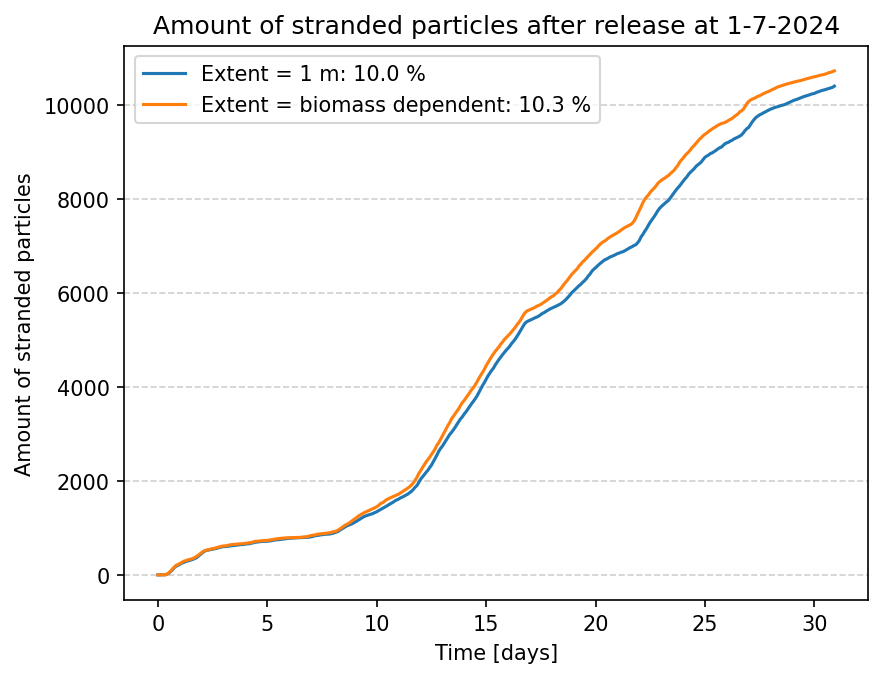

In [21]:
#print(len(DSAAN.trajectory)) ?????????????????????????????????????????????????????????

DSSs = [DSS1, DSS2de]
labels = ['Extent = 1 m', 'Extent = biomass dependent']

strand = []
strand_percentage = []
print('Length: ', len(DSL1.trajectory))
for ds in DSSs:
    # sum stranded particles along the obs dimension (axis=0)
    print(ds.sizes)
    print(len(ds.obs))
    until = len(ds.obs)
    stranded_sum = np.sum(ds.stranded[:,:
    ], axis=0)
    strand.append(stranded_sum)
    stranded_percentage = 100 * stranded_sum / len(ds.trajectory)
    strand_percentage.append(stranded_percentage)

# Convert to a numpy array if needed
strand = np.array(strand)
strand_percentage=np.array(strand_percentage)
print(strand.shape, strand_percentage.shape)
#print(strand_percentage[:,-1])
print(2148/77245)
fig = plt.figure(dpi=150)
for i in range(len(DSSs)):
    until = len(DSSs[i].obs)
    print(until)
    plt.plot(time_in_days[0,:until], strand[i,:until], label = f'{labels[i]}: {strand_percentage[i,-1]:.1f} %')
#lt.plot(time_in_days[0,:], strand)
plt.xlabel('Time [days]')
plt.ylabel('Amount of stranded particles')
plt.legend()
plt.title(f'Amount of stranded particles after release at 1-7-2024')
#plt.title(f'Stranded particels = {(100*strand[-1].values/(len(DSL1.trajectory))):.2f} % of total')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

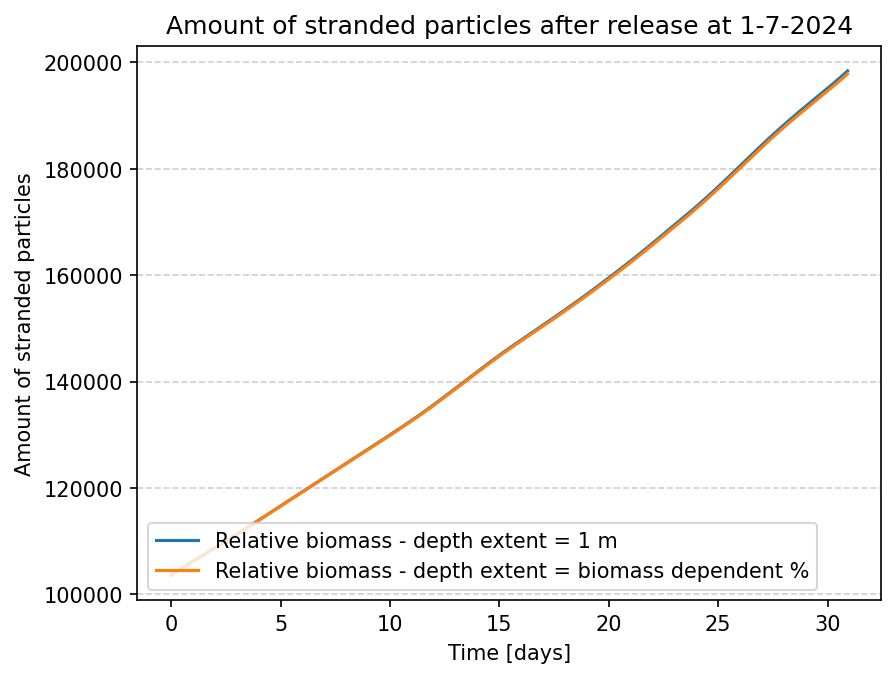

In [24]:
fig = plt.figure(dpi=150)

biomass = [E['biomass_SF3'].sum(dim='trajectory')     for E in DSSs]  

biomass = np.array(biomass)

#biomass_loss = [E['biomass_loss'].sum(dim='trajectory')     for E in DSSs]  
#biomass_loss = np.array(biomass_loss)
plt.plot(time_in_days[0,:], biomass[0,:].T, label = f'Relative biomass - depth extent = 1 m')
plt.plot(time_in_days[0,:], biomass[1,:].T, label = f'Relative biomass - depth extent = biomass dependent %')
#plt.plot(time_in_days[0,:], biomass_loss.T, label = f'Loss  %')
#lt.plot(time_in_days[0,:], strand)
plt.xlabel('Time [days]')
plt.ylabel('Amount of stranded particles')
plt.legend(loc='lower left')
plt.title(f'Amount of stranded particles after release at 1-7-2024')
#plt.title(f'Stranded particels = {(100*strand[-1].values/(len(DSL1.trajectory))):.2f} % of total')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

[-64.37564174 -64.37519096 -64.37504939 ... -13.7668091  -13.76796213
 -13.70558052]
0


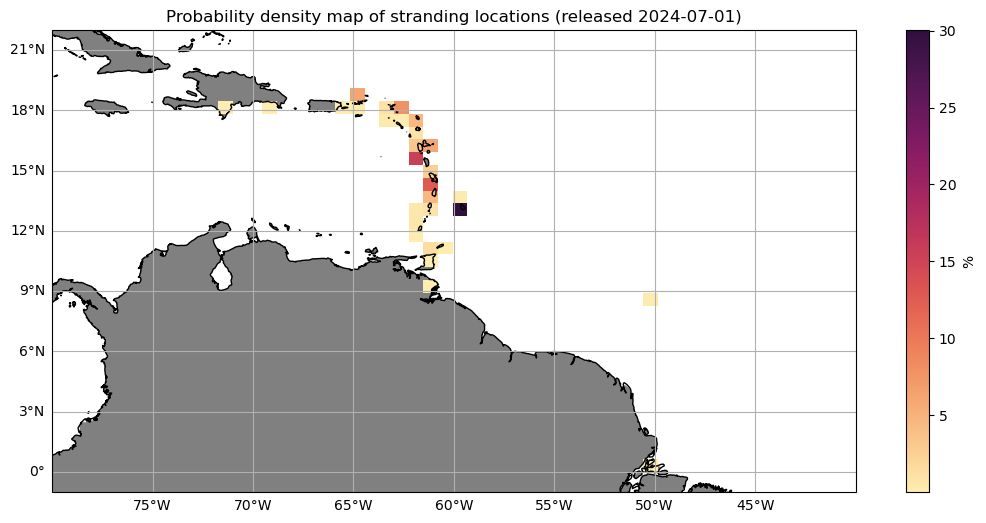

In [33]:
bins_x = 80
bins_y = 30

DSS1_lasttimestep = DSS1.isel(obs=-1)
stranded =  DSS1_lasttimestep.where(DSS1_lasttimestep['stranded'].compute()==1, drop=True)    #for X in DSLs] 

print(stranded.lon.values)
print(np.isnan(stranded.lon.values).sum())  # should be 0 ideally

probability = c_H.probability_density(stranded, bins_x, bins_y)
probability_last = c_H.probability_density(DSS1_lasttimestep, bins_x, bins_y)

#choose the limits of the x & y axis of the graph
xlim=[-80, -40]
ylim= [-1, 22]

stranded
#plot the results
c_H.probability_map(probability, xlim, ylim, f'Probability density map of stranding locations (released {starttimejul.date()})', None)

In [25]:
def categorized_biomass_plot(DATA,  DIV, COLORMAP, STARTTIME, FINAL=True):
    #Categorizing based on weight and multiplying by category step size #SO THIS VALUE IS THE UPPER BOUNDARY OF THE BIN THAT THE PARTICLE WEIGHT IS CLASSIFIED IN!!!!
    categorized_id = np.digitize(DATA.biomass_SF3, DIV, right=False) #get bin indices for each weight (np.digitize gives the bin index of each weight)
    categorized_upper = DIV[categorized_id]
    categorized_lower = DIV[categorized_id - 1]
    DATA["biomass_SF3_categorized"] = (DATA.biomass_SF3.dims, categorized_lower) #Stores lower boundary of category that particle weight is in in dataset

    #Settings for the colormap and colorbar
    number_of_bins = len(DIV)
    boundaries = DIV
    # #colormap = plt.cm.get_cmap('plasma', number_of_bins )
    #colormap = plt.cm.get_cmap('YlGnBu', number_of_bins )
    #norm = mcolors.BoundaryNorm(boundaries[:], number_of_bins)
    colormap = COLORMAP
    norm = mcolors.BoundaryNorm(boundaries[:], ncolors=colormap.N, clip=False)

    #FIGURE
    fig = plt.figure(figsize = (10,7), dpi=250)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

    if FINAL == True:
        cscat = ax.scatter(DATA.lon[:,-1], DATA.lat[:,-1], c = DATA.biomass_SF3_categorized[:,-1].values,
        cmap=colormap, norm=norm, s=1, linewidth=0, transform=ccrs.PlateCarree(), zorder=1)
    else:
    #Colored scatter plot with STARTING lon, lat and FINAL values of the categorized weight
        cscat = ax.scatter(DATA.lon[:,0], DATA.lat[:,0], c = DATA.biomass_SF3_categorized[:,-1].values,
        cmap=colormap, norm=norm, s=1, linewidth=0, transform=ccrs.PlateCarree(), zorder=1)

    #Plotting of stranded particles settings
    # if DATA['stranded'].any() == 1:
    #     print('there are stranded particles')
    #     mask = (DSL1['stranded']==1).compute()
    #     stranded_slice = DSL1.where(mask, drop=True)
    #     ax.scatter(stranded_slice.lon, stranded_slice.lat, c='tab:green', s=0.5)
    # else:
    #     print('no stranded particles')

    #Other figure settings
    ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=2)
    ax.add_feature(cartopy.feature.LAND.with_scale('10m'),zorder=3)
    if FINAL == True:
        ax.set_title(f'Relative biomass after 31 days (released {STARTTIME.date()})')
    else:
        ax.set_title(f'Relative biomass after 31 days for initial location (released {STARTTIME.date()})')
    #ax.set_extent([-78,-15,-4,19])
    #ax.set_extent([-75,-18,-3,17])
    #ax.set_extent([-59,-50,3,12])
    cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Relative biomass category', shrink=0.5)
    return plt.show()

#categorized_weight_plot(DSL3, div, cmo.algae, starttimejan, FINAL=False)

MAX:  3.8132164  MIN:  0.585163


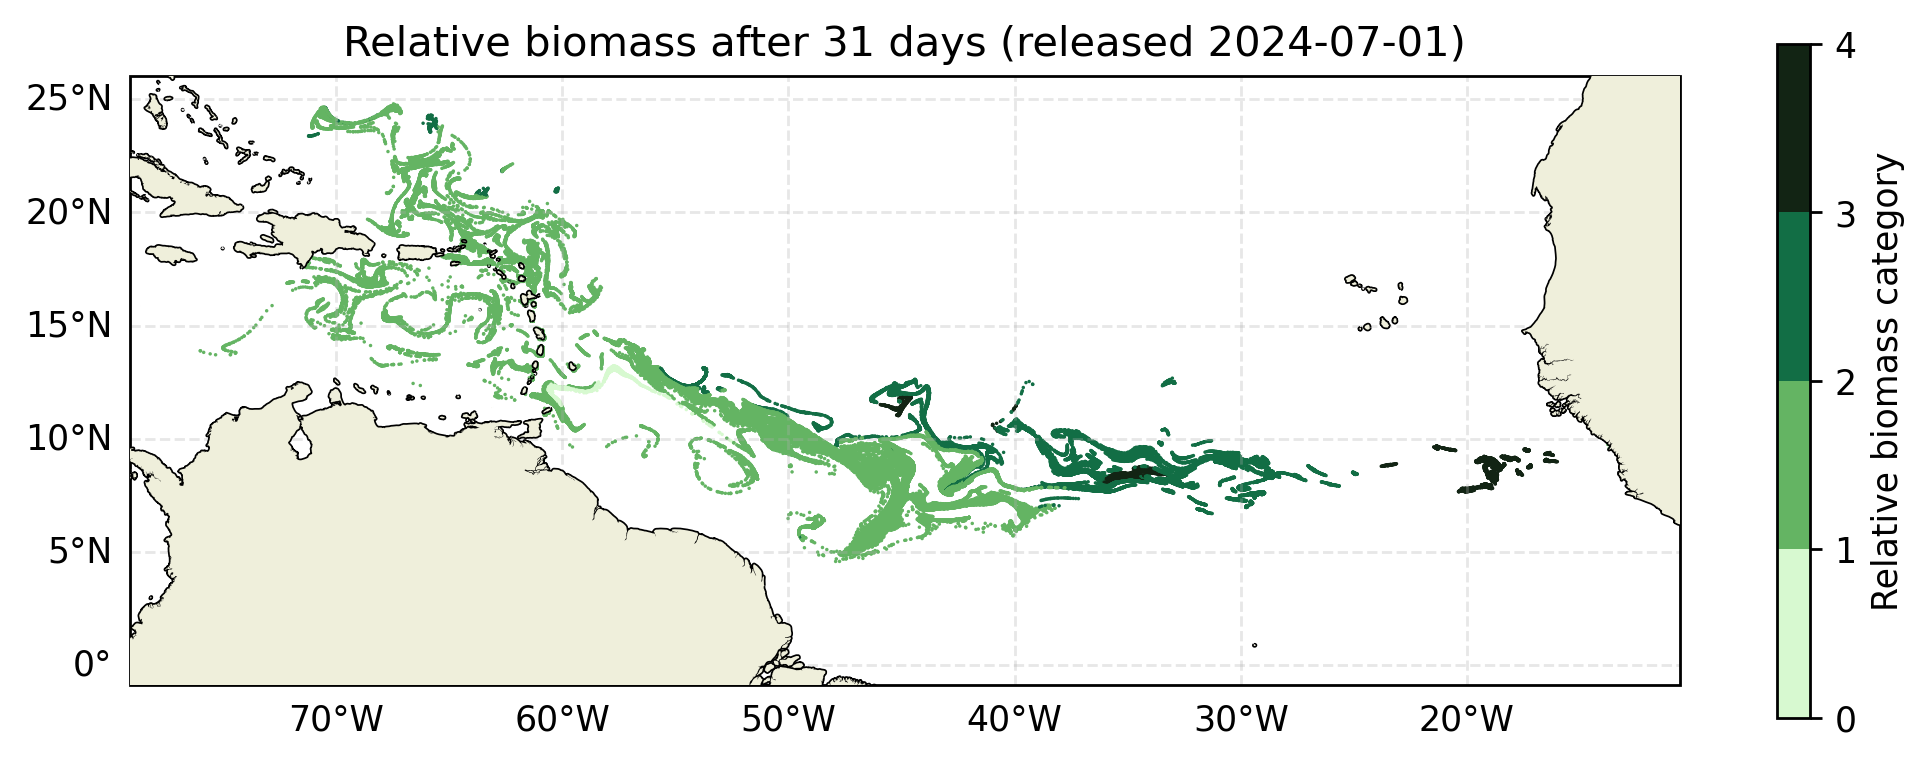

In [27]:
#Evaluating the min and max to be able to define the right categories #DEZE PLOT DUS ALS EEN FUNCTIE!!!!
max_SF3 = np.nanmax(DSS1.biomass_SF3)
min_SF3 = np.nanmin(DSS1.biomass_SF3)
print('MAX: ', max_SF3, ' MIN: ',min_SF3)

div = np.linspace(0, 4, 5)   #creating 9 equally spaced bin edges between 0 and 400
categorized_biomass_plot(DSS1, div, cmo.algae, starttimejul, FINAL=True)

MAX:  379.30432  MIN:  50.0
Div : [  0.  50. 100. 150. 200. 250.]
Number of particles with weight > 350 g: 30510
Number of particles with weight cat = 400 g: 0


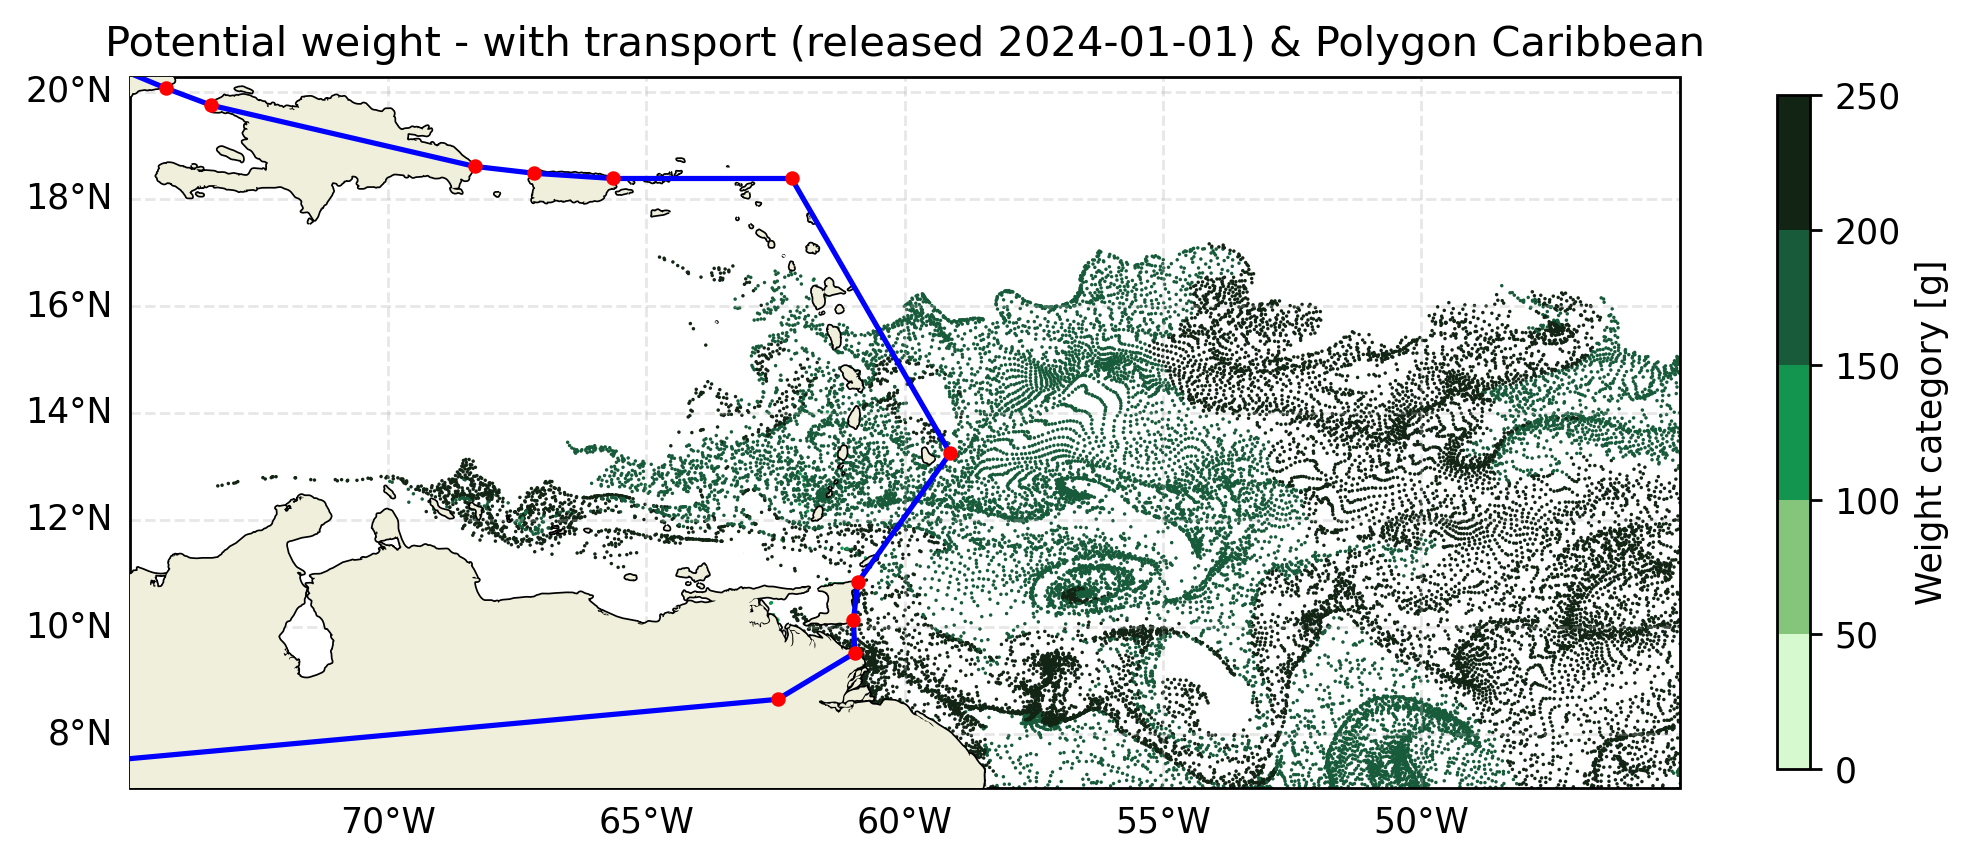

In [ ]:
#Evaluating the min and max to be able to define the right categories #DEZE PLOT DUS ALS EEN FUNCTIE!!!!
max_SF3 = np.nanmax(DSL1.weight_SN1)
min_SF3 = np.nanmin(DSL1.weight_SN1)
print('MAX: ', max_SF3, ' MIN: ',min_SF3)

#DEFINING THE CATEGORIES
div = np.linspace(0, 250, 6)   #creating 9 equally spaced bin edges between 0 and 400
print('Div :',div)             #
div_step = div[1]-div[0]       #calculating bin step size (interval width)

#Categorizing based on weight and multiplying by category step size #SO THIS VALUE IS THE UPPER BOUNDARY OF THE BIN THAT THE PARTICLE WEIGHT IS CLASSIFIED IN!!!!
categorized_id = np.digitize(DSL1.weight_SF3, div, right=False) #get bin indices for each weight (np.digitize gives the bin index of each weight)
categorized_upper = div[categorized_id]
categorized_lower = div[categorized_id - 1]
DSL1["weight_SF3_categorized"] = (DSL1.weight_SF3.dims, categorized_lower) #Stores lower boundary of category that particle weight is in in dataset

#TO CHECK: Count how many particles are heavier than 350 g and how many particles are assigned in this category
num_above_350 = np.sum(DSL1.weight_SN1.values > 350)
num_highest_cat = np.sum(DSL1.weight_SF3_categorized.values == 350)
print(f"Number of particles with weight > 350 g: {num_above_350}")
print(f"Number of particles with weight cat = 400 g: {num_highest_cat}")

#Settings for the colormap and colorbar
number_of_bins = len(div)
boundaries = div
#colormap = plt.cm.get_cmap('plasma', number_of_bins )
#norm = mcolors.BoundaryNorm(boundaries[:], number_of_bins)
colormap = cmo.algae
norm = mcolors.BoundaryNorm(boundaries[:], ncolors=colormap.N, clip=False)


plt.show()#FIGURE
fig = plt.figure(figsize = (10,7), dpi=250)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.gridlines(draw_labels=['left','bottom'], zorder=2, alpha=0.3, linestyle='--')

#Colored scatter plot with STARTING lon, lat and FINAL values of the categorized weight
cscat = ax.scatter(DSL1.lon[:,-1], DSL1.lat[:,-1], c = DSL1.weight_SF3_categorized[:,-1].values,
    cmap=colormap, norm=norm, s=1, linewidth=0, transform=ccrs.PlateCarree(), zorder=1
)

#Plotting of stranded particles settings
# if DSL1['stranded'].any() == 1:
#     print('there are stranded particles')
#     mask = (DSL1['stranded']==1).compute()
#     stranded_slice = DSL1.where(mask, drop=True)
#     ax.scatter(stranded_slice.lon, stranded_slice.lat, c='tab:green', s=0.5)
# else:
#     print('no stranded particles')

#Other figure settings
ax.add_feature(cartopy.feature.COASTLINE.with_scale('10m'), zorder=2)
ax.add_feature(cartopy.feature.LAND.with_scale('10m'),zorder=3)
gdf_poly.boundary.plot(ax=ax, color='blue',zorder=4)
gdf.plot(ax=ax, color='red', markersize=10,zorder=5)
ax.set_title(f'Potential weight - with transport (released {starttimejan.date()}) & Polygon Caribbean')
#ax.set_extent([-86,7,-7,19])
ax.set_extent([-75,-45,7,20])
#ax.set_extent([-90,-18,-3,20])
cbar = plt.colorbar(cscat, ax=ax, orientation='vertical', label='Weight category [g]', shrink=0.5)